# Addition experiment
## create two data manifolds X1, X2, each of dimension N * d and tail exponents alpha_Xi
## calculate PP(Xi) and actual alpha_Xi
## define X12 = X1 + X2
## calculate PP(X12) and actual alpha_X12
### PatnaikPearson_addition_20260507.ipynb



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

## Experiment One : fix N and d. Choose alpha_Xi randomly
## N = 1000, d = 500

In [9]:
num_iterations = 100

min_alpha = 0.1
max_alpha = 4.0
scale_factor = max_alpha - min_alpha

this_N = 1000
this_d = 500

alpha_X1_vals = np.zeros(num_iterations)
alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1_vals = np.zeros(num_iterations)
actual_alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1plusX2_vals = np.zeros(num_iterations)
estimate_alpha_X1plusX2_vals = np.zeros(num_iterations)
pp_dim_X1_vals = np.zeros(num_iterations)
pp_dim_X2_vals = np.zeros(num_iterations)
pp_dim_X1plusX2_vals = np.zeros(num_iterations)
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1plusX2_vals = np.zeros(num_iterations)
estimate_nu_over_d_X1plusX2_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    this_alpha_X1 = min_alpha + scale_factor * np.random.uniform(0,1)
    this_alpha_X2 = min_alpha + scale_factor * np.random.uniform(0,1)

    results_dict = pp.addition_experiment(this_N, this_d, this_alpha_X1, this_alpha_X2)

    actual_alpha_X1 = results_dict["actual_alpha_X1"]
    actual_alpha_X2 = results_dict["actual_alpha_X2"]
    actual_alpha_X1plusX2 = results_dict["actual_alpha_X1plusX2"]
    pp_dim_X1 = results_dict["pp_dim_X1"] 
    pp_dim_X2 = results_dict["pp_dim_X2"]
    pp_dim_X1plusX2 = results_dict["pp_dim_X1plusX2"] 
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"] 
    nu_over_d_X1plusX2 = results_dict["nu_over_d_X1plusX2"] 
    
    alpha_X1_vals[i] = this_alpha_X1
    alpha_X2_vals[i] = this_alpha_X2
    actual_alpha_X1_vals[i] = actual_alpha_X1
    actual_alpha_X2_vals[i] = actual_alpha_X2
    actual_alpha_X1plusX2_vals[i] = actual_alpha_X1plusX2
    estimate_alpha_X1plusX2 = min(actual_alpha_X1, actual_alpha_X2)
    estimate_alpha_X1plusX2_vals[i] = estimate_alpha_X1plusX2
    pp_dim_X1_vals[i] = pp_dim_X1
    pp_dim_X2_vals[i] = pp_dim_X2
    pp_dim_X1plusX2_vals[i] = pp_dim_X1plusX2
    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1plusX2_vals[i] = nu_over_d_X1plusX2
    estimate_nu_over_d_X1plusX2 = min(nu_over_d_X1, nu_over_d_X2)
    estimate_nu_over_d_X1plusX2_vals[i] = estimate_nu_over_d_X1plusX2
    print(i, actual_alpha_X1, actual_alpha_X2, actual_alpha_X1plusX2, estimate_alpha_X1plusX2)

0 1.8768339645685999 2.818048913358533 2.1270169372351786 1.8768339645685999
1 2.6439333625797277 2.5687297144494914 2.7971616114905062 2.5687297144494914
2 0.9212286793426391 1.9381675670243677 1.0002139350379984 0.9212286793426391
3 1.995568981538617 1.1972977325567848 1.3030718678557889 1.1972977325567848
4 2.385316059289156 2.176547001765108 2.409680954025303 2.176547001765108
5 2.056491218960715 2.48113962557855 2.352306552976927 2.056491218960715
6 2.371090194988157 2.6782784770766517 2.665175777147028 2.371090194988157
7 2.4176491290901025 2.40587491899023 2.5864127274663034 2.40587491899023
8 1.9128441058999606 1.5142056445993017 1.7721825134771587 1.5142056445993017
9 0.9665945760790996 2.7283407879306014 0.9922420070148119 0.9665945760790996
10 2.4823788659380623 2.416182042457847 2.5988656829957377 2.416182042457847
11 2.0495319438149506 1.3653817867448967 1.5004785194204522 1.3653817867448967
12 0.5166857988531077 1.7226862604967759 0.5166857989793682 0.5166857988531077
13 

[]

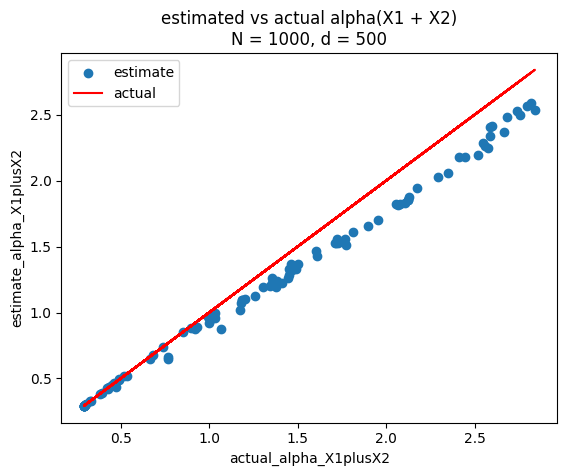

In [10]:
this_title = "estimated vs actual alpha(X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(actual_alpha_X1plusX2_vals, estimate_alpha_X1plusX2_vals, label="estimate")
plt.plot(actual_alpha_X1plusX2_vals, actual_alpha_X1plusX2_vals, color="red", label="actual")
plt.xlabel("actual_alpha_X1plusX2")
plt.ylabel("estimate_alpha_X1plusX2")
plt.legend()
plt.title(this_title)
plt.savefig('alpha_X1_plus_X2.pdf', dpi=300, bbox_inches='tight')
plt.plot()

[]

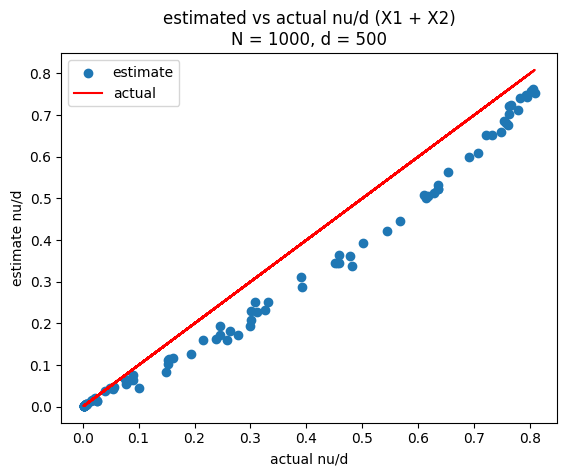

In [11]:
this_title = "estimated vs actual nu/d (X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(nu_over_d_X1plusX2_vals, estimate_nu_over_d_X1plusX2_vals, label="estimate")
plt.plot(nu_over_d_X1plusX2_vals, nu_over_d_X1plusX2_vals, color="red", label="actual")
plt.xlabel("actual nu/d")
plt.ylabel("estimate nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_X1_plus_X2.pdf', dpi=300, bbox_inches='tight')
plt.plot()